In [1]:
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn  as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import root_mean_squared_error,  mean_absolute_percentage_error, mean_absolute_error

# PARTIE 1

In [2]:
# Importation des fichier csv 

client_id = pd.read_csv("data/clients.csv") # Information du client

produit = pd.read_csv("data/produits.csv")

commande_pass = pd.read_csv("data/commandes.csv") #Importation du fichier contenant les commandes de l'annees passe (2025)

fournisseurs = pd.read_csv("data/fournisseurs.csv")  ## Fichier contennant les infos des fournisseurs

avis_clients = pd.read_csv("data/avis.csv")  # Importation du fichier contenant les avis des clients apres livraison

### 1-) Analyse du fichier contenant les infos de chacuns de nos clients

In [3]:
client_id.head()

,client_id,nom,age,sexe,ville,date_inscription,segment
0,1,Kodjo Adjei,24.0,M,Kpalimé,2025-08-10,Nouveau
1,2,Dede Agbeko,20.0,M,Lomé,23/09/2023,Régulier
2,3,Akpene Tchassa,29.0,F,Dapaong,2025-12-11,Nouveau
3,4,Afi Tchassa,39.0,M,kpalime,2023-07-11,VIP
4,5,Sena Sossou,19.0,M,Atakpamé,07/05/2022,Régulier


In [4]:
client_id.tail()

,client_id,nom,age,sexe,ville,date_inscription,segment
256,257,Kodjo Agbeko,26.0,F,kara,2022-06-05,Nouveau
257,258,Essi Sossou,33.0,M,kpalime,19/02/2025,NaN
258,259,Afi Tchassa,21.0,F,Atakpamé,06/10/2022,Régulier
259,260,Sena Adjei,33.0,M,KARA,2023-11-25,VIP
260,11,Kekeli Dossou,20.0,F,Sokodé,24/07/2022,Régulier


In [5]:
client_id.shape[0] # Nombre total de lignes 

261

In [6]:
client_id.info() # verification des types de donnees et valeurs manquantes

<class 'pandas.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         261 non-null    int64  
 1   nom               261 non-null    str    
 2   age               249 non-null    float64
 3   sexe              261 non-null    str    
 4   ville             261 non-null    str    
 5   date_inscription  261 non-null    str    
 6   segment           251 non-null    str    
dtypes: float64(1), int64(1), str(5)
memory usage: 23.6 KB


In [7]:
client_id.isnull().sum()  # compteur des valeurs manquantes 

client_id            0
nom                  0
age                 12
sexe                 0
ville                0
date_inscription     0
segment             10
dtype: int64

In [8]:
client_id["age"] = client_id["age"].fillna(client_id["age"].median()) #Remplacement des valeur manquantes par la mediane
client_id.isnull().sum()

client_id            0
nom                  0
age                  0
sexe                 0
ville                0
date_inscription     0
segment             10
dtype: int64

In [9]:
client_id["age"] = client_id["age"].astype(int) # Correction du type d'age DE FLOAT EN  INTEGER

In [10]:
client_id.info() # 

<class 'pandas.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   client_id         261 non-null    int64
 1   nom               261 non-null    str  
 2   age               261 non-null    int64
 3   sexe              261 non-null    str  
 4   ville             261 non-null    str  
 5   date_inscription  261 non-null    str  
 6   segment           251 non-null    str  
dtypes: int64(2), str(5)
memory usage: 23.6 KB


-  Correction des valeur **manquantes sur la colonne segment**

In [11]:
client_id["segment"] = client_id["segment"].fillna("Inconnue") # Remplacer les valeurs manquantes par *Inconnue*

In [12]:
client_id.isnull().sum()

client_id           0
nom                 0
age                 0
sexe                0
ville               0
date_inscription    0
segment             0
dtype: int64

- Verification des ***doublons***

In [13]:
client_id.duplicated().sum()

np.int64(1)

In [14]:
client_id.drop_duplicates(inplace = True)  #Suppression des doublons 

In [15]:
client_id.duplicated().sum()

np.int64(0)

- Correction des dates de la colonne ***date inscription***

In [16]:
client_id["date_inscription"] = pd.to_datetime(client_id["date_inscription"],
                                               format = "mixed",  
                                               dayfirst = True,
                                               errors = "coerce").dt.strftime("%d/%m/%Y")

In [17]:
client_id.head()  ## Correction reussi avec succes

,client_id,nom,age,sexe,ville,date_inscription,segment
0,1,Kodjo Adjei,24,M,Kpalimé,08/10/2025,Nouveau
1,2,Dede Agbeko,20,M,Lomé,23/09/2023,Régulier
2,3,Akpene Tchassa,29,F,Dapaong,12/11/2025,Nouveau
3,4,Afi Tchassa,39,M,kpalime,07/11/2023,VIP
4,5,Sena Sossou,19,M,Atakpamé,07/05/2022,Régulier


<h5 style = "color :red">verification des erreur d'ecrit dans les vaariables nom, age , sexe, ville, segment</h5>

- Variable ***nom***

In [18]:
client_id["nom"].unique()

<ArrowStringArray>
[   'Kodjo Adjei',    'Dede Agbeko', 'Akpene Tchassa',    'Afi Tchassa',
    'Sena Sossou',    'Sena Kpodar',   'Kodjo Kpodar',    'Dede Bakoma',
   'Adjoa Sossou',  'Kekeli Dossou',
 ...
   'Kossi Sossou',   'Essi Tchassa',    'Komi Sossou',    'Fofo Sossou',
    'Sena Agbeko',     'Afi Bakoma',  'Kossi Amouzou',   'Mawuli Adjei',
  'Mawuli Agbeko', 'Kekeli Amouzou']
Length: 107, dtype: str

***Apres analyse il y'a pas de valeur minuscule melange avec majiscule qui pourrai compromettre a  l';analyse donc la variable est sans probleme***

- Variable **sexe** :

In [19]:
client_id["sexe"].unique()

<ArrowStringArray>
['M', 'F']
Length: 2, dtype: str

variable sexe est sans probleme

- Variable **ville** :

In [20]:
client_id["ville"].unique()

<ArrowStringArray>
[ 'Kpalimé',    'Lomé ',  'Dapaong',  'kpalime', 'Atakpamé', 'atakpame',
     'Lomé',   'Sokodé',   'sokode',     'Kara',     'LOME',   'Sokode',
     'KARA',     'lome', 'dapaong ',    ' Lomé',     'kara']
Length: 17, dtype: str

In [21]:
client_id["ville"] = client_id["ville"].str.lower() #Convertir tout les villes en miniscule

In [22]:
client_id["ville"].unique()

<ArrowStringArray>
[ 'kpalimé',    'lomé ',  'dapaong',  'kpalime', 'atakpamé', 'atakpame',
     'lomé',   'sokodé',   'sokode',     'kara',     'lome', 'dapaong ',
    ' lomé']
Length: 13, dtype: str

In [23]:
client_id["ville"] = client_id["ville"].astype("string").str.strip("' ")  #Supprimer les espaces entre mot et guie;llemets

In [24]:
client_id["ville"].unique()

<ArrowStringArray>
[ 'kpalimé',     'lomé',  'dapaong',  'kpalime', 'atakpamé', 'atakpame',
   'sokodé',   'sokode',     'kara',     'lome']
Length: 10, dtype: string

In [25]:
client_id["ville"]  = client_id["ville"].replace({ # Rempolacerment des nom des pays par les nom correctes
    "kpalime"   : "Kpalimé",
    "atakpame"  : "Atakpamé",
    "sokode"    : "Sokodé",
    "lome"      : "Lomé",
    "kara"      : "Kara",
    "dapaong"   : "Dapaong",
    "lomé"      :  "Lomé",
    "kpalimé"   :  "Kpalimé",
    "atakpamé"  :  "Atakpamé",
    "sokodé"    :  "Sokodé"
})

In [26]:
client_id["ville"].unique() 

<ArrowStringArray>
['Kpalimé', 'Lomé', 'Dapaong', 'Atakpamé', 'Sokodé', 'Kara']
Length: 6, dtype: string

- Variable segment

In [27]:
client_id["segment"].unique()

<ArrowStringArray>
['Nouveau', 'Régulier', 'VIP', 'Inconnue']
Length: 4, dtype: str

In [28]:
client_id.head()

,client_id,nom,age,sexe,ville,date_inscription,segment
0,1,Kodjo Adjei,24,M,Kpalimé,08/10/2025,Nouveau
1,2,Dede Agbeko,20,M,Lomé,23/09/2023,Régulier
2,3,Akpene Tchassa,29,F,Dapaong,12/11/2025,Nouveau
3,4,Afi Tchassa,39,M,Kpalimé,07/11/2023,VIP
4,5,Sena Sossou,19,M,Atakpamé,07/05/2022,Régulier


---

<p style = "color : red">Verificattion et suppression des valeur impossible</p>

In [29]:
client_id.query("client_id<0")	#Pas de valeur impossible dans la variable client_id 

,client_id,nom,age,sexe,ville,date_inscription,segment


In [30]:
client_id.query("age <= 0")

,client_id,nom,age,sexe,ville,date_inscription,segment
247,248,Komi Sossou,-3,F,Lomé,21/03/2024,Régulier


In [31]:
#On troouve une valeur donc supprimons automatiquement cette ligne 

In [32]:
client_id = client_id.drop(client_id[client_id["age"]<0].index)

In [33]:
client_id.query("age <= 0") #La suppression termite plus de valeur impossible dans le dtataset 

,client_id,nom,age,sexe,ville,date_inscription,segment


---

<p style = "color : red">Verification et correction s'il y'en a des valeur aberantes dans la variable de l'age</p>

In [34]:
client_id.sort_values("age").tail()

,client_id,nom,age,sexe,ville,date_inscription,segment
162,163,Afi Amouzou,50,F,Lomé,26/08/2023,Nouveau
49,50,Dede Kpodar,51,F,Atakpamé,13/02/2025,Nouveau
58,59,Komi Bakoma,53,F,Lomé,21/02/2022,Régulier
148,149,Elom Dossou,57,M,Dapaong,21/11/2022,Régulier
123,124,Fofo Kpodar,180,F,Kara,07/08/2023,Nouveau


In [35]:
## Un age aberant de 180ans c;est pas possile donc supprimons cette ligne 

In [36]:
client_id["age"] = client_id["age"].replace({180 : 18})

In [37]:
client_id.sort_values("age").tail()

,client_id,nom,age,sexe,ville,date_inscription,segment
184,185,Kekeli Sossou,50,M,Sokodé,08/01/2024,Régulier
155,156,Sena Kpodar,50,M,Atakpamé,09/08/2025,Régulier
49,50,Dede Kpodar,51,F,Atakpamé,13/02/2025,Nouveau
58,59,Komi Bakoma,53,F,Lomé,21/02/2022,Régulier
148,149,Elom Dossou,57,M,Dapaong,21/11/2022,Régulier


In [38]:
client_id.sort_values("age", ascending= False).head()

,client_id,nom,age,sexe,ville,date_inscription,segment
148,149,Elom Dossou,57,M,Dapaong,21/11/2022,Régulier
58,59,Komi Bakoma,53,F,Lomé,21/02/2022,Régulier
49,50,Dede Kpodar,51,F,Atakpamé,13/02/2025,Nouveau
174,175,Elom Dossou,50,M,Dapaong,11/11/2024,Nouveau
155,156,Sena Kpodar,50,M,Atakpamé,09/08/2025,Régulier


In [39]:
#age de 180ans supprimer avec succes, non je se vais remplacer par 18ans car je pense que c'est plausible

### 2-)Analyse du fichier contenant les produits de l'entreprise

In [40]:
produit.head()

,product_id,category,brand,cost_price,list_price,stock_quantity,supplier_id
0,1,Cyclisme,Vela,41.0,95.5,333,2
1,2,Running,Kaito,40.1,56.3,199,5
2,3,Running,Atlas,24.2,42.8,136,2
3,4,Yoga,Kaito,23.4,46.8,233,4
4,5,Basketball,Prime,36.9,79.2,136,6


In [41]:
produit.tail()

,product_id,category,brand,cost_price,list_price,stock_quantity,supplier_id
86,87,Yoga,Nova,44.8,NaN,101,6
87,88,Basketball,Kaito,21.4,35.7,205,1
88,89,Football,Nova,25.6,39.7,67,2
89,90,Basketball,Prime,24.9,40.3,65,5
90,4,Yoga,Kaito,23.4,46.8,238,4


In [42]:
produit.shape[0] # Nombre de licgne de ce dataset

91

In [43]:
produit.head()

,product_id,category,brand,cost_price,list_price,stock_quantity,supplier_id
0,1,Cyclisme,Vela,41.0,95.5,333,2
1,2,Running,Kaito,40.1,56.3,199,5
2,3,Running,Atlas,24.2,42.8,136,2
3,4,Yoga,Kaito,23.4,46.8,233,4
4,5,Basketball,Prime,36.9,79.2,136,6


In [44]:
produit.info()

<class 'pandas.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      91 non-null     int64  
 1   category        91 non-null     str    
 2   brand           91 non-null     str    
 3   cost_price      91 non-null     float64
 4   list_price      86 non-null     float64
 5   stock_quantity  91 non-null     int64  
 6   supplier_id     91 non-null     int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 6.2 KB


- Correction des valeurs manquantes

In [45]:
produit.isnull().sum()

product_id        0
category          0
brand             0
cost_price        0
list_price        5
stock_quantity    0
supplier_id       0
dtype: int64

catalogue_produit.dropna(inplace = True)  # j'ai supprimer toutes les lignes contenant des prix de ventes 
                                        # manquantes par ce que pour moi cela n'agit pas de trop sur no article

In [46]:
produit.isnull().sum()

product_id        0
category          0
brand             0
cost_price        0
list_price        5
stock_quantity    0
supplier_id       0
dtype: int64

- Verification des doublons

In [47]:
produit.duplicated().sum()  # Zero doublon dans ce dataset

np.int64(0)

<h5 style = "color : red">Verification des  erreur d'ecriture dans les variables categorie_sport et marque</h5>

- Variable **categorie_sport**

In [48]:
produit["category"].unique()

<ArrowStringArray>
[   'Cyclisme',     'Running',        'Yoga',  'Basketball',    'Football',
   'football ',  'BASKETBALL',     'Fitness',    'FOOTBALL',    'running ',
    'fitness ',       'yoga ', 'basketball ',    'CYCLISME',   'cyclisme ']
Length: 15, dtype: str

- On remarque qu'il y'a des nom comme Cyclisme, CYCLISME, cyclisme pour l'etre humains on considere cela que 
c'est la meme chose mais pandas lui va penser qu'il sont diff donc corrrigosn cela

In [49]:
produit["category"] = produit["category"].astype("string").str.strip("'")

In [50]:
produit["category"].unique()

<ArrowStringArray>
[   'Cyclisme',     'Running',        'Yoga',  'Basketball',    'Football',
   'football ',  'BASKETBALL',     'Fitness',    'FOOTBALL',    'running ',
    'fitness ',       'yoga ', 'basketball ',    'CYCLISME',   'cyclisme ']
Length: 15, dtype: string

In [51]:
produit["category"] = produit["category"].str.lower()

In [52]:
produit["category"].unique()

<ArrowStringArray>
[   'cyclisme',     'running',        'yoga',  'basketball',    'football',
   'football ',     'fitness',    'running ',    'fitness ',       'yoga ',
 'basketball ',   'cyclisme ']
Length: 12, dtype: string

- <p style = "color : red">Changement des noms des variables de notre dataframe contenant les produits</p>

In [53]:
produit.rename({
    "product_id"      : "id_produit",
     "category"       : "categorie",
     "brand"          : "marque",
     "cost_price"     : "prix_achat",
     "list_price"     : "prix_vente",
     "stock_quantity" : "stock_dispo",
     "supplier_id"    : "ref_fournisseur"
}, axis = 1, inplace = True)

In [54]:
produit.head()

,id_produit,categorie,marque,prix_achat,prix_vente,stock_dispo,ref_fournisseur
0,1,cyclisme,Vela,41.0,95.5,333,2
1,2,running,Kaito,40.1,56.3,199,5
2,3,running,Atlas,24.2,42.8,136,2
3,4,yoga,Kaito,23.4,46.8,233,4
4,5,basketball,Prime,36.9,79.2,136,6


<p style = "color : red">Verification des valeur impossible</p>

In [55]:
produit.query("	prix_achat<0")

,id_produit,categorie,marque,prix_achat,prix_vente,stock_dispo,ref_fournisseur
18,19,football,Prime,-31.8,49.6,338,6
73,74,running,Atlas,-31.1,70.5,162,6


- Dans la variable 	***prix_achat***	

In [56]:
produit["prix_achat"] = produit["prix_achat"].replace({
    -31.8	: 31.8,
    -31.1	: 31.1	
})

In [57]:
produit.query("	prix_achat<0") # J'ai remplacer les vaelur negatifs par + car selon moi l'
#erreur est plaussible c'est une erreur de saisie

,id_produit,categorie,marque,prix_achat,prix_vente,stock_dispo,ref_fournisseur


- Dans la variable ***prix_vente***

In [58]:
produit.query("prix_vente<0")

,id_produit,categorie,marque,prix_achat,prix_vente,stock_dispo,ref_fournisseur


In [59]:
#Aucune valeur negatif

- Dans la variable 	***stock_dispo***

In [60]:
produit.query("	stock_dispo<0")

,id_produit,categorie,marque,prix_achat,prix_vente,stock_dispo,ref_fournisseur


In [61]:
#Aucune valeur negatif

- Dans la variable ***ref_fournisseur***

In [62]:
produit.query("ref_fournisseur<0")

,id_produit,categorie,marque,prix_achat,prix_vente,stock_dispo,ref_fournisseur


In [63]:
#Aucune valeur negatif

### 3-) Analyse et netoyage du fichier commande_pass 

In [64]:
commande_pass.head()

,order_id,date,client_id,product_id,quantity,discount_pct,payment_method,region,delivery_time_days,status
0,1,02/01/2025,70,31,2,0,Paiement à la livraison,Kpalimé,3.2,Livrée
1,2,2025-01-02,218,85,1,15,carte,Kara,4.3,Livrée
2,3,2025-01-02,158,62,1,0,Mobile Money,Lomé,2.2,Livrée
3,4,2025-01-03,205,76,1,0,Mobile_Money,Kara,6.1,Livrée
4,5,2025-01-03,250,47,2,15,Mobile Money,Sokodé,3.8,Livrée


- <p style = "color : red">changement des noms de nos variables</p>

In [65]:
commande_pass.rename({
       "order_id"           :  "id_unique",
       "date"               :  "date_commande",
       "client_id"          :  "id_client",
       "product_id"         :  "id_produit",
       "quantity"           :  "quantite",
       "discount_pct"       :  "reduction(%)",
       "payment_method"     :  "mode_payement",
       "region"             :  "region",
       "delivery_time_days" :  "delai_livraison",
}, axis = 1, inplace  = True)

In [66]:
commande_pass.head() 
# Pour les lignes dont livraison est vide == > livraison en cours

,id_unique,date_commande,id_client,id_produit,quantite,reduction(%),mode_payement,region,delai_livraison,status
0,1,02/01/2025,70,31,2,0,Paiement à la livraison,Kpalimé,3.2,Livrée
1,2,2025-01-02,218,85,1,15,carte,Kara,4.3,Livrée
2,3,2025-01-02,158,62,1,0,Mobile Money,Lomé,2.2,Livrée
3,4,2025-01-03,205,76,1,0,Mobile_Money,Kara,6.1,Livrée
4,5,2025-01-03,250,47,2,15,Mobile Money,Sokodé,3.8,Livrée


In [67]:
commande_pass.shape[0]  # Nomcbre de ligne 

1237

In [68]:
commande_pass.info()

<class 'pandas.DataFrame'>
RangeIndex: 1237 entries, 0 to 1236
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_unique        1237 non-null   int64  
 1   date_commande    1237 non-null   str    
 2   id_client        1237 non-null   int64  
 3   id_produit       1237 non-null   int64  
 4   quantite         1237 non-null   int64  
 5   reduction(%)     1237 non-null   int64  
 6   mode_payement    1237 non-null   str    
 7   region           1237 non-null   str    
 8   delai_livraison  1126 non-null   float64
 9   status           1237 non-null   str    
dtypes: float64(1), int64(5), str(4)
memory usage: 138.2 KB


In [69]:
commande_pass.isnull().sum()  #Pour les delai de livraison  , les valeur manquante  ==> indique que la commande est en cours 

id_unique            0
date_commande        0
id_client            0
id_produit           0
quantite             0
reduction(%)         0
mode_payement        0
region               0
delai_livraison    111
status               0
dtype: int64

- <p style = "color :red">Correction des erreur dans les dates</p>

In [70]:
commande_pass["date_commande"].unique()    # Il y'a des erreur , donc je dois modifier 

<ArrowStringArray>
['02/01/2025', '2025-01-02', '2025-01-03', '03/01/2025', '2025-01-04',
 '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08', '2025-01-09',
 ...
 '2025-12-25', '25/12/2025', '2025-12-26', '26/12/2025', '2025-12-27',
 '2025-12-28', '2025-12-29', '29/12/2025', '2025-12-30', '2025-12-31']
Length: 470, dtype: str

In [ ]:
commande_pass["date_commande"] = pd.to_datetime(
    commande_pass["date_commande"], 
    format = "mixed",
    dayfirst = True,
    errors = "coerce"
).dt.strftime("%d/%m/%Y")

In [72]:
commande_pass["date_commande"].unique() # Correction , en faite j'ai reconvertie en format francais

<ArrowStringArray>
['02/01/2025', '01/02/2025', '01/03/2025', '03/01/2025', '01/04/2025',
 '01/05/2025', '01/06/2025', '01/07/2025', '01/08/2025', '01/09/2025',
 ...
 '22/12/2025', '23/12/2025', '24/12/2025', '25/12/2025', '26/12/2025',
 '27/12/2025', '28/12/2025', '29/12/2025', '30/12/2025', '31/12/2025']
Length: 345, dtype: str

---

  <p style = "color : red">Verification des erreur de saisie</p>

- Dans la variable  ***mode_payement***

In [73]:
commande_pass.head()

,id_unique,date_commande,id_client,id_produit,quantite,reduction(%),mode_payement,region,delai_livraison,status
0,1,02/01/2025,70,31,2,0,Paiement à la livraison,Kpalimé,3.2,Livrée
1,2,01/02/2025,218,85,1,15,carte,Kara,4.3,Livrée
2,3,01/02/2025,158,62,1,0,Mobile Money,Lomé,2.2,Livrée
3,4,01/03/2025,205,76,1,0,Mobile_Money,Kara,6.1,Livrée
4,5,01/03/2025,250,47,2,15,Mobile Money,Sokodé,3.8,Livrée


In [74]:
commande_pass["mode_payement"].unique()

<ArrowStringArray>
['Paiement à la livraison',                   'carte',
            'Mobile Money',            'Mobile_Money',
                    'MOMO',          'Carte bancaire',
                    'cash',            'mobile money',
                      'CB',     'Cash a la livraison']
Length: 10, dtype: str

In [75]:
# Les modes de payment que moi je vois la me semble trop bizzarre, mais sais que ceux ci sont des modes de payement  :
#  - Par Carte banquaire
#  - cash (Paieyemment a a la livraison)
#  - mobile_money
# Le reste je ne connais pas donc je vais les remplacer:

# Deja je peut dire que ce son des erreur de saisie car:
# MOMO == >Mobile Money , certains qiue cette personne voulais ecrire Mobile Money mais a voulu abreger

In [76]:
commande_pass["mode_payement"] = commande_pass["mode_payement"].str.lower() # Convertion des nom en minuscule 

In [77]:
commande_pass["mode_payement"].unique()

<ArrowStringArray>
['paiement à la livraison',                   'carte',
            'mobile money',            'mobile_money',
                    'momo',          'carte bancaire',
                    'cash',                      'cb',
     'cash a la livraison']
Length: 9, dtype: str

In [78]:
commande_pass["mode_payement"] = commande_pass["mode_payement"].replace({
    "momo"                    :     "mobile_money",
    "cash a la livraison"     :     "paiement à la livraison",
    "carte"                   :    "carte_bancaire",
    "cash"                    :    "paiement à la livraison",
    "cb"                     :    "carte_bancaire",
    "mobile money"            :    "mobile_money"
})

In [79]:
commande_pass["mode_payement"].unique() # Correctgion effectue avec succes

<ArrowStringArray>
['paiement à la livraison', 'carte_bancaire', 'mobile_money',
 'carte bancaire']
Length: 4, dtype: str

- Dans la variable  ***region***

In [80]:
commande_pass["region"].unique() #On trouve auccun problenm dde saisie dans cette variable 

<ArrowStringArray>
['Kpalimé', 'Kara', 'Lomé', 'Sokodé', 'Atakpamé', 'Dapaong']
Length: 6, dtype: str

- Dans la variable  ***status***

In [81]:
commande_pass["status"].unique() #Aucun probcleme 

<ArrowStringArray>
['Livrée', 'En cours', 'Annulée', 'Retournée']
Length: 4, dtype: str

---

- <p style = "color : red ">Verification et correction des doublon de notre dataset commande_pass</p>

In [82]:
commande_pass.duplicated().sum()  # verification des docublon 

np.int64(1)

In [83]:
commande_pass.drop_duplicates(inplace = True)

In [84]:
commande_pass.duplicated().sum()

np.int64(0)

In [85]:
commande_pass.head()

,id_unique,date_commande,id_client,id_produit,quantite,reduction(%),mode_payement,region,delai_livraison,status
0,1,02/01/2025,70,31,2,0,paiement à la livraison,Kpalimé,3.2,Livrée
1,2,01/02/2025,218,85,1,15,carte_bancaire,Kara,4.3,Livrée
2,3,01/02/2025,158,62,1,0,mobile_money,Lomé,2.2,Livrée
3,4,01/03/2025,205,76,1,0,mobile_money,Kara,6.1,Livrée
4,5,01/03/2025,250,47,2,15,mobile_money,Sokodé,3.8,Livrée


 <p style = "color : red">Verification des valeurs impossibles et correction de ces valeur dans le dataset commande</p>

- Dans la variable ***id_unique***

In [86]:
commande_pass.query("id_unique<0")

,id_unique,date_commande,id_client,id_produit,quantite,reduction(%),mode_payement,region,delai_livraison,status


Pas de valeur impossible dans la variable identifant unique

- Dans la variable ***id_client***

In [87]:
commande_pass.query(" id_client<0 ")

,id_unique,date_commande,id_client,id_produit,quantite,reduction(%),mode_payement,region,delai_livraison,status


Pas de valeur impossible dans la variable identifant unique

- Dans la variable ***id_produit***

In [88]:
commande_pass.query(" id_produit<0")

,id_unique,date_commande,id_client,id_produit,quantite,reduction(%),mode_payement,region,delai_livraison,status


Pas de valeur impossible dans la variable identifant unique

- Dans la variable ***quantite***

In [89]:
commande_pass.query("quantite<=0")

,id_unique,date_commande,id_client,id_produit,quantite,reduction(%),mode_payement,region,delai_livraison,status
43,44,17/01/2025,233,39,-1,10,mobile_money,Atakpamé,4.6,Livrée
57,58,22/01/2025,241,20,-1,0,mobile_money,Dapaong,4.9,Livrée
649,650,16/07/2025,133,64,-1,0,mobile_money,Kara,1.9,Annulée
664,665,23/07/2025,221,88,-1,20,carte_bancaire,Lomé,1.0,Retournée


In [90]:
# Suppression des valeur impossible <0 ==>quantite negatif

commande_pass["quantite"] = commande_pass["quantite"].replace({-1 : 1})

In [91]:
commande_pass.query(" id_produit<0")

,id_unique,date_commande,id_client,id_produit,quantite,reduction(%),mode_payement,region,delai_livraison,status


In [92]:
#Suppression reussi avec succees

### 4 -Analyse et netoyage du fichier fournisseurs

In [93]:
fournisseurs.head()

,supplier_id,supplier_name,country,lead_time_days,reliability_score
0,1,AfricaSport Import,Togo,3,4.6
1,2,GlobalGear Ltd,Chine,21,4.1
2,3,EuroFit Distribution,France,12,4.7
3,4,SahelTex,Côte d'Ivoire,6,3.9
4,5,Prime Athletics,Chine,25,NaN


- <p style = "color : red">Changement des noms des variable(nenommer)</p>

In [94]:
fournisseurs.rename({
    "supplier_id"       :      "id_unique",
    "supplier_name"     :      "nom_fournisseur",
    "country"           :      "pays",
    "lead_time_days"    :      "delai_approvision(jours)",
    "reliability_score" :      "score_fiabilte"
}, axis = 1, inplace = True)

In [95]:
fournisseurs

,id_unique,nom_fournisseur,pays,delai_approvision(jours),score_fiabilte
0,1,AfricaSport Import,Togo,3,4.6
1,2,GlobalGear Ltd,Chine,21,4.1
2,3,EuroFit Distribution,France,12,4.7
3,4,SahelTex,Côte d'Ivoire,6,3.9
4,5,Prime Athletics,Chine,25,NaN
5,6,Naija Sports Supply,Nigeria,8,4.0


Le fournisseur de ***la chine*** n'a pas donner son score, Sinon ce dataset est deja propres

### 5 - Analyse et netoyage du fichier avis_clients

In [96]:
avis_clients.head()

,review_id,order_id,rating,comment_length
0,1,813,5.0,16
1,2,56,4.0,128
2,3,1145,3.0,93
3,4,683,4.0,77
4,5,312,4.0,61


- <p style = "color : red">Modification des nom des variable(renommer)</p>

In [97]:
avis_clients.rename({
    "review_id"       :        "id_unique",
     "order_id"       :        "ref_commande",
     "rating"         :        "note_laissee",
     "comment_length" :        "longueur_comment"
}, axis = 1, inplace = True)

In [98]:
avis_clients.head()

,id_unique,ref_commande,note_laissee,longueur_comment
0,1,813,5.0,16
1,2,56,4.0,128
2,3,1145,3.0,93
3,4,683,4.0,77
4,5,312,4.0,61


## HAAAAA !!!! QUELLE JOIE FIN DU NETOYAGE AVEC SUCCES

---

# PARTIE 2

In [99]:
# fusion du fichier clients id et commande , 
client_id.head()

,client_id,nom,age,sexe,ville,date_inscription,segment
0,1,Kodjo Adjei,24,M,Kpalimé,08/10/2025,Nouveau
1,2,Dede Agbeko,20,M,Lomé,23/09/2023,Régulier
2,3,Akpene Tchassa,29,F,Dapaong,12/11/2025,Nouveau
3,4,Afi Tchassa,39,M,Kpalimé,07/11/2023,VIP
4,5,Sena Sossou,19,M,Atakpamé,07/05/2022,Régulier


In [100]:
commande_pass.head()

,id_unique,date_commande,id_client,id_produit,quantite,reduction(%),mode_payement,region,delai_livraison,status
0,1,02/01/2025,70,31,2,0,paiement à la livraison,Kpalimé,3.2,Livrée
1,2,01/02/2025,218,85,1,15,carte_bancaire,Kara,4.3,Livrée
2,3,01/02/2025,158,62,1,0,mobile_money,Lomé,2.2,Livrée
3,4,01/03/2025,205,76,1,0,mobile_money,Kara,6.1,Livrée
4,5,01/03/2025,250,47,2,15,mobile_money,Sokodé,3.8,Livrée


In [101]:
commande_pass.shape[0]

1236

In [102]:
produit.head()

,id_produit,categorie,marque,prix_achat,prix_vente,stock_dispo,ref_fournisseur
0,1,cyclisme,Vela,41.0,95.5,333,2
1,2,running,Kaito,40.1,56.3,199,5
2,3,running,Atlas,24.2,42.8,136,2
3,4,yoga,Kaito,23.4,46.8,233,4
4,5,basketball,Prime,36.9,79.2,136,6


In [103]:
produit.shape[0]

91

In [104]:
df = pd.merge(commande_pass , produit, on = "id_produit", how = "inner") 
# moi pour la fusion entre le dataset commande_pass et celui des prodcuit , j'ai decider de garder que les lignes qui sont tous remplie
#car le dataset produit ne peut pas fausser mes calculer car vaux mieux de ne pas connaitre l 

In [105]:
df.head()

,id_unique,date_commande,id_client,id_produit,quantite,reduction(%),mode_payement,region,delai_livraison,status,categorie,marque,prix_achat,prix_vente,stock_dispo,ref_fournisseur
0,1,02/01/2025,70,31,2,0,paiement à la livraison,Kpalimé,3.2,Livrée,cyclisme,Nova,30.5,71.7,380,4
1,2,01/02/2025,218,85,1,15,carte_bancaire,Kara,4.3,Livrée,cyclisme,Atlas,8.6,NaN,61,1
2,3,01/02/2025,158,62,1,0,mobile_money,Lomé,2.2,Livrée,basketball,Nova,20.8,32.5,76,4
3,4,01/03/2025,205,76,1,0,mobile_money,Kara,6.1,Livrée,fitness,Vela,13.2,30.5,236,5
4,5,01/03/2025,250,47,2,15,mobile_money,Sokodé,3.8,Livrée,yoga,Prime,7.8,11.2,173,1


In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1244 entries, 0 to 1243
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_unique        1244 non-null   int64  
 1   date_commande    1244 non-null   str    
 2   id_client        1244 non-null   int64  
 3   id_produit       1244 non-null   int64  
 4   quantite         1244 non-null   int64  
 5   reduction(%)     1244 non-null   int64  
 6   mode_payement    1244 non-null   str    
 7   region           1244 non-null   str    
 8   delai_livraison  1133 non-null   float64
 9   status           1244 non-null   str    
 10  categorie        1244 non-null   string 
 11  marque           1244 non-null   str    
 12  prix_achat       1244 non-null   float64
 13  prix_vente       1163 non-null   float64
 14  stock_dispo      1244 non-null   int64  
 15  ref_fournisseur  1244 non-null   int64  
dtypes: float64(3), int64(7), str(5), string(1)
memory usage: 218.1 KB


In [107]:
df.describe().round(2)

,id_unique,id_client,id_produit,quantite,reduction(%),delai_livraison,prix_achat,prix_vente,stock_dispo,ref_fournisseur
count,1244.00,1244.00,1244.00,1244.00,1244.00,1133.00,1244.00,1163.00,1244.00,1244.00
mean,618.46,164.39,45.49,1.70,4.06,3.81,25.06,49.32,216.82,3.48
std,356.40,563.61,26.31,0.74,5.79,1.55,11.14,22.37,123.00,1.71
min,1.00,1.00,1.00,1.00,0.00,1.00,6.10,11.20,5.00,1.00
25%,311.75,71.75,23.00,1.00,0.00,2.70,15.30,29.80,99.00,2.00
50%,617.50,135.00,46.00,2.00,0.00,3.80,23.40,46.80,230.00,4.00
75%,926.25,197.00,67.00,2.00,10.00,4.90,35.40,66.90,338.00,5.00
max,1236.00,9999.00,90.00,3.00,20.00,8.40,44.80,100.40,397.00,6.00



### Phase 4 — Exploration graphique et interprétation

Réponds, graphe(s) à l'appui, aux questions suivantes posées par l'entreprise. **Formule d'abord la question en tes propres mots, choisis ensuite le ou les graphes adaptés, puis interprète** — ne te contente jamais d'un graphe sans un paragraphe qui dit ce qu'il montre.

1. **Direction générale** — Le chiffre d'affaires (à calculer à partir de `quantity`, `list_price`, `discount_pct`) évolue-t-il de façon particulière sur l'année ? Y a-t-il des tendances exploitables pour anticiper les stocks ?
2. **Direction générale** — Quelles catégories de produits génèrent le plus de marge (`list_price - cost_price`) ? Est-ce cohérent avec ce qui se vend le plus (`quantity`) ?
3. **Qualité** — Le délai de livraison influence-t-il la note laissée par les clients ? Cette relation est-elle la même dans toutes les régions ?
4. **Qualité** — Les fournisseurs avec un `lead_time_days` élevé ont-ils un impact visible sur le stock ou sur les délais de livraison des produits qu'ils fournissent ?
5. **Marketing** — Le profil des clients VIP (âge, ville, ancienneté) diffère-t-il de celui des clients Nouveaux ? Le mode de paiement varie-t-il selon la région ?
6. **Marketing** — Certains produits ont-ils un stock très déséquilibré par rapport à leurs ventes (sur-stock ou rupture imminente) ?
7. **Direction générale** — Existe-t-il des variables numériques du jeu de données fusionné fortement corrélées entre elles ? Toutes les variables numériques disponibles ont-elles un sens à être incluses dans cette analyse ?

Pour chaque question, sois attentif à ce que ton graphe **ne cache pas** une partie de la réponse (moyenne sans dispersion, proportions avec trop de catégories, variables sans rapport incluses dans une corrélation, etc.).

## Visualisation

In [108]:
df.head()

,id_unique,date_commande,id_client,id_produit,quantite,reduction(%),mode_payement,region,delai_livraison,status,categorie,marque,prix_achat,prix_vente,stock_dispo,ref_fournisseur
0,1,02/01/2025,70,31,2,0,paiement à la livraison,Kpalimé,3.2,Livrée,cyclisme,Nova,30.5,71.7,380,4
1,2,01/02/2025,218,85,1,15,carte_bancaire,Kara,4.3,Livrée,cyclisme,Atlas,8.6,NaN,61,1
2,3,01/02/2025,158,62,1,0,mobile_money,Lomé,2.2,Livrée,basketball,Nova,20.8,32.5,76,4
3,4,01/03/2025,205,76,1,0,mobile_money,Kara,6.1,Livrée,fitness,Vela,13.2,30.5,236,5
4,5,01/03/2025,250,47,2,15,mobile_money,Sokodé,3.8,Livrée,yoga,Prime,7.8,11.2,173,1


In [109]:
df.isnull().mean()*100 #Pourcentages des valeur manquantes

id_unique          0.000000
date_commande      0.000000
id_client          0.000000
id_produit         0.000000
quantite           0.000000
reduction(%)       0.000000
mode_payement      0.000000
region             0.000000
delai_livraison    8.922830
status             0.000000
categorie          0.000000
marque             0.000000
prix_achat         0.000000
prix_vente         6.511254
stock_dispo        0.000000
ref_fournisseur    0.000000
dtype: float64

In [110]:
df["prix_vente"] = df["prix_vente"].fillna(df["prix_vente"].median()) #Remplacer fles prix de ventes manquantes par la median

In [111]:
df.isnull().mean()*100 

id_unique          0.00000
date_commande      0.00000
id_client          0.00000
id_produit         0.00000
quantite           0.00000
reduction(%)       0.00000
mode_payement      0.00000
region             0.00000
delai_livraison    8.92283
status             0.00000
categorie          0.00000
marque             0.00000
prix_achat         0.00000
prix_vente         0.00000
stock_dispo        0.00000
ref_fournisseur    0.00000
dtype: float64

1. **Direction générale** — Le chiffre d'affaires (à calculer à partir de `quantity`, `list_price`, `discount_pct`) évolue-t-il de façon particulière sur l'année ? Y a-t-il des tendances exploitables pour anticiper les stocks ?

In [112]:
df["Chiffre_Affaire"]  = df["quantite"]*df["prix_vente"]*(1- df["reduction(%)"]/100)

In [113]:
df.head()

,id_unique,date_commande,id_client,id_produit,quantite,reduction(%),mode_payement,region,delai_livraison,status,categorie,marque,prix_achat,prix_vente,stock_dispo,ref_fournisseur,Chiffre_Affaire
0,1,02/01/2025,70,31,2,0,paiement à la livraison,Kpalimé,3.2,Livrée,cyclisme,Nova,30.5,71.7,380,4,143.40
1,2,01/02/2025,218,85,1,15,carte_bancaire,Kara,4.3,Livrée,cyclisme,Atlas,8.6,46.8,61,1,39.78
2,3,01/02/2025,158,62,1,0,mobile_money,Lomé,2.2,Livrée,basketball,Nova,20.8,32.5,76,4,32.50
3,4,01/03/2025,205,76,1,0,mobile_money,Kara,6.1,Livrée,fitness,Vela,13.2,30.5,236,5,30.50
4,5,01/03/2025,250,47,2,15,mobile_money,Sokodé,3.8,Livrée,yoga,Prime,7.8,11.2,173,1,19.04


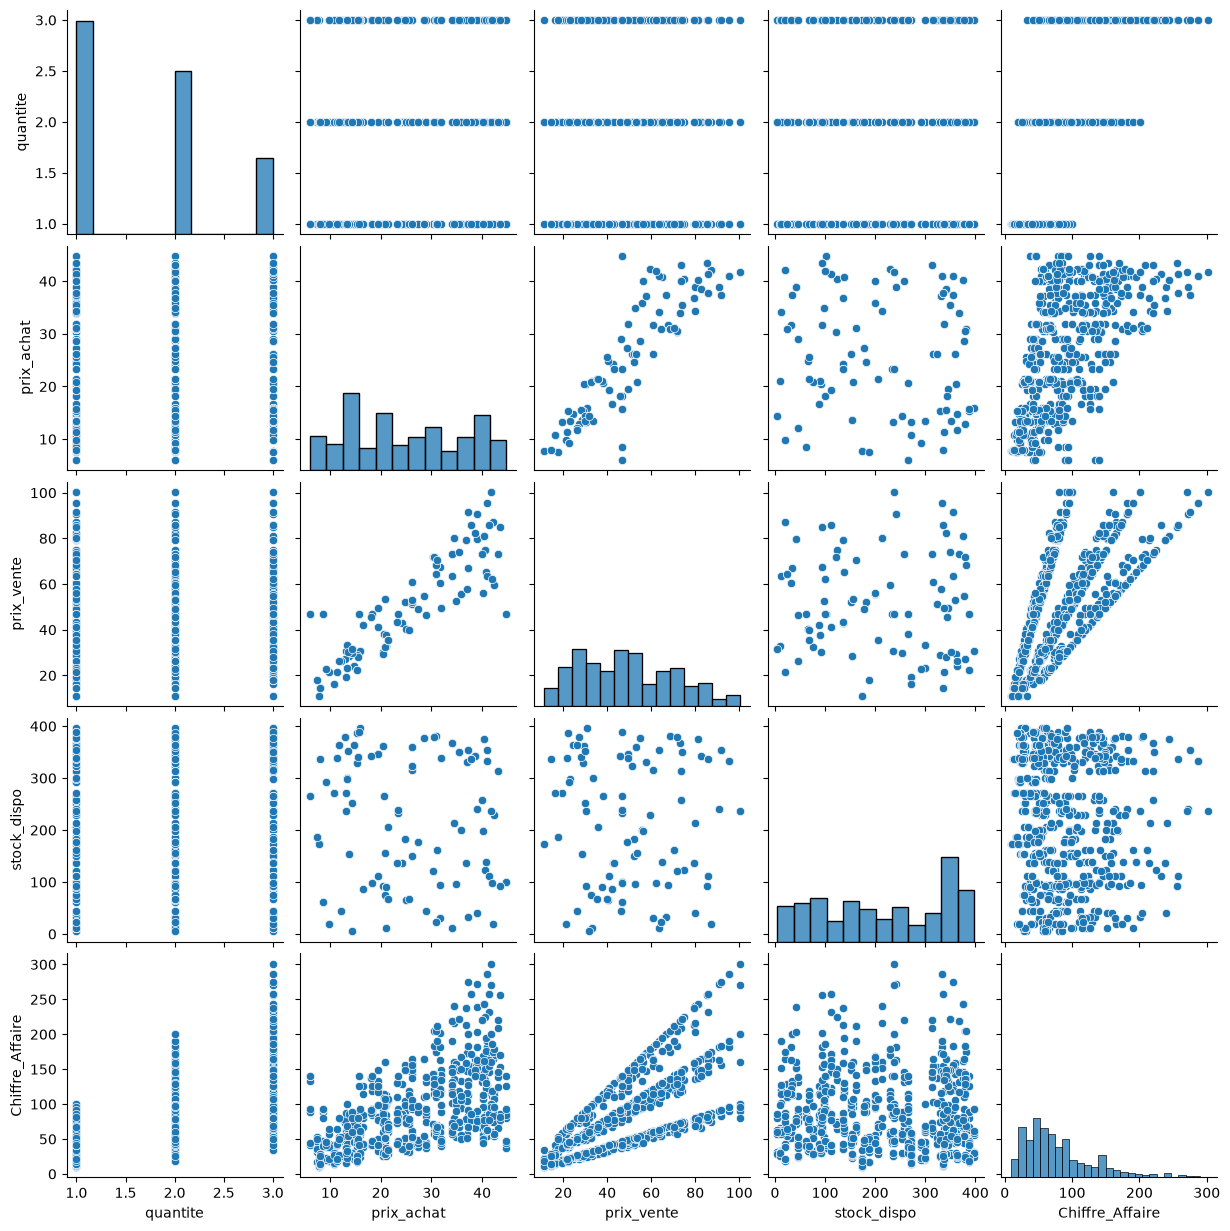

In [114]:
sns.pairplot(df[["quantite","prix_achat","prix_vente","stock_dispo","Chiffre_Affaire"]])

<Axes: title={'center': "Chiffre d'affaire par region"}, xlabel='Chiffre_Affaire', ylabel='region'>

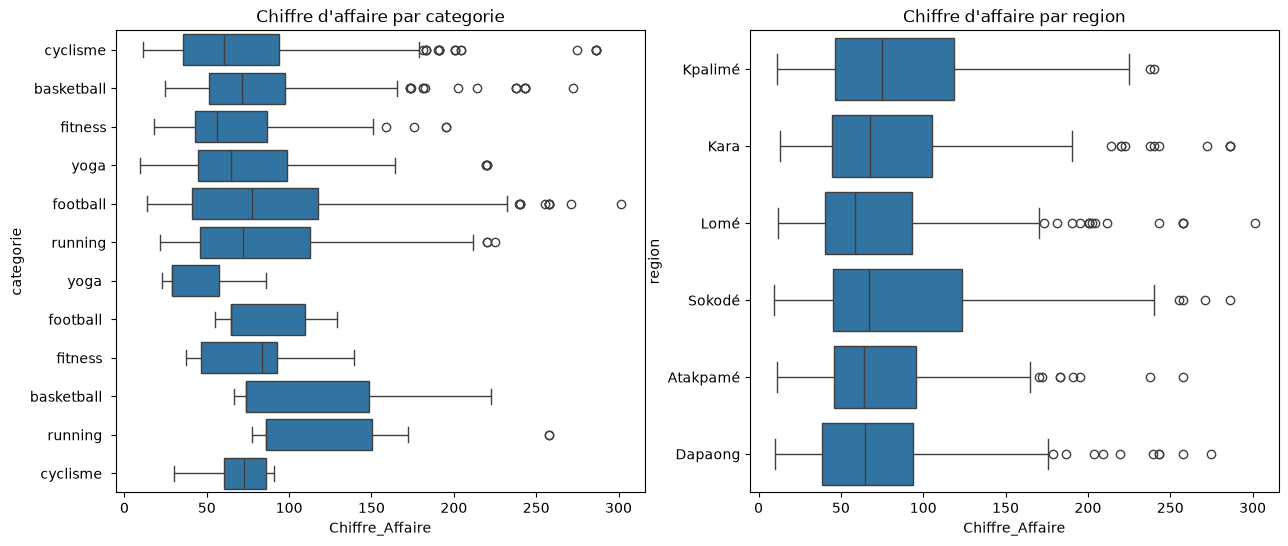

In [115]:
plt.figure(figsize = (15,6))
plt.subplot(1,2,1)
plt.title("Chiffre d'affaire par categorie")
sns.boxplot(data=df, x = "Chiffre_Affaire", y= "categorie")
plt.subplot(1,2,2)
plt.title("Chiffre d'affaire par region")
sns.boxplot(data=df, x = "Chiffre_Affaire", y= "region")

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5]),
 [Text(0, 0.5, 'quantite'),
  Text(0, 1.5, 'prix_achat'),
  Text(0, 2.5, 'prix_vente'),
  Text(0, 3.5, 'stock_dispo'),
  Text(0, 4.5, 'Chiffre_Affaire'),
  Text(0, 5.5, 'reduction(%)')])

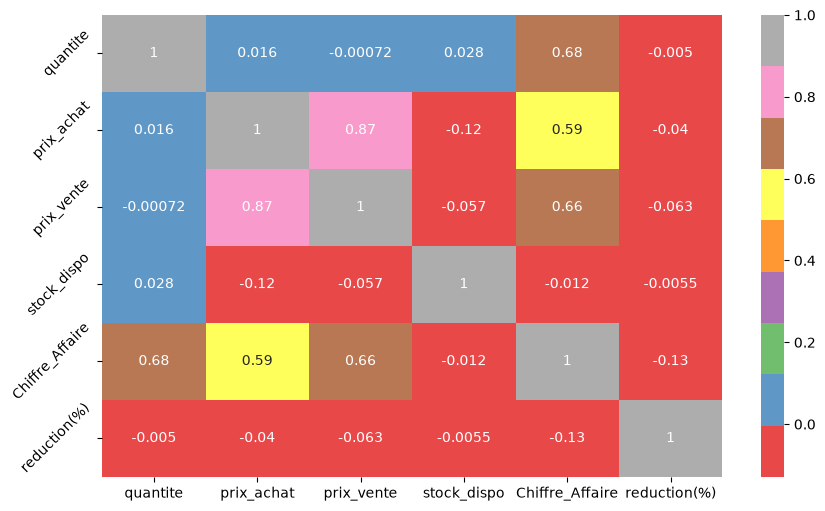

In [116]:
plt.figure(figsize = (10, 6))
sns.heatmap(df[["quantite","prix_achat","prix_vente","stock_dispo","Chiffre_Affaire", "reduction(%)"]].corr(numeric_only = True), cmap = "Set1",alpha = 0.8, annot = True)
plt.xticks(rotation = 0)
plt.yticks(rotation = 45)

In [117]:
X = df[["quantite","prix_achat","prix_vente"]]
y = df["Chiffre_Affaire"]

X.shape

(1244, 3)

In [118]:
X_train, X_test,  y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

print(f"- Donnees Entrainement :{X_train.shape}\n- Donnees de l'evaluation : {X_test.shape}")

- Donnees Entrainement :(995, 3)
- Donnees de l'evaluation : (249, 3)


In [119]:
## Tracons les courbes de la regression 

<Axes: title={'center': 'CA = a*prix_vente + bruit'}, xlabel='prix_vente', ylabel='Chiffre_Affaire'>

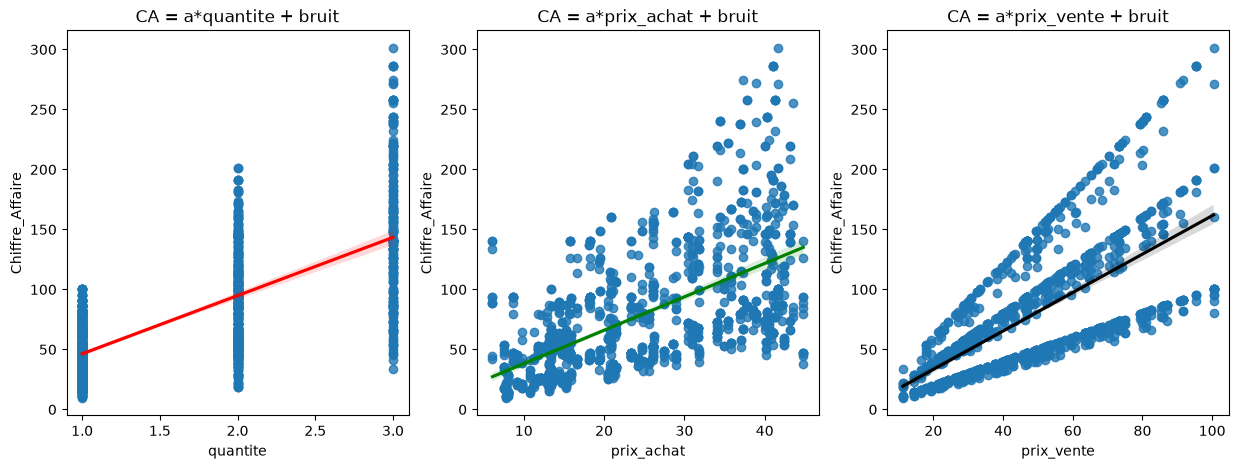

In [120]:
plt.figure(figsize = (15,5))
plt.subplot(1,3,1)
plt.title("CA = a*quantite + bruit")
sns.regplot(data = X, x = "quantite", y = y, line_kws = {"color" : "red"})
plt.subplot(1,3,2)
plt.title("CA = a*prix_achat + bruit")
sns.regplot(data = X, x= "prix_achat", y = y , line_kws = {"color" : "green"})
plt.subplot(1,3,3)
plt.title("CA = a*prix_vente + bruit")
sns.regplot(data = X, x= "prix_vente", y = y , line_kws = {"color" : "black"})

In [121]:
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_train, y_train)

0.903674911917394

In [122]:
val_score = cross_val_score(model, X_train, y_train, cv= 5)
val_score

array([0.90783989, 0.90830223, 0.89509593, 0.89179675, 0.90831239])

In [123]:
val_score.mean()

np.float64(0.9022694353529028)

In [124]:
## Teste sur ;les donnees d'evaluationn
model.score(X_test, y_test)

0.8970604027603802

In [125]:
mae = root_mean_squared_error(y_test, model.predict(X_test))
mape = mean_absolute_percentage_error(y_test, model.predict(X_test))
print(" MAPE :",round(mape,2)*100, "%")

 MAPE : 24.0 %


In [126]:
# Le model n'esr pas assezz performant dut a certaine chifffre d'affaire trop eleve